# 03 · Customers: segments, repeat buying and lifetime value

**Question:** who are the store's customers, do they come back, and which ones are worth chasing?

A customer here is a browser that placed at least one order (GA4 tracks cookies, not people). The data covers 92 days, and only 7.5% of customers bought on more than one day, so this is mostly a story about one-off buyers. The methods are chosen with that in mind.

| Table | What it holds |
|---|---|
| `marts.dim_customers` | one row per customer with RFM scores and segment (dbt, SQL) |
| `marts.customer_clv` | chance each customer is still active, expected repeat buying (dbt Python model) |

In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from marketing_analytics.customers import expected_purchases, fit, summarise
from marketing_analytics.style import PAL, apply, finish

apply()
con = duckdb.connect("../warehouse.duckdb", read_only=True)
IMG = "../figures/customers"


## 1 · RFM segments

Each customer gets a recency score (days since last purchase, in bands), a spend score (quintiles) and a frequency band (buying days: 1, 2, 3+). The segment rules are in `sql/models/marts/dim_customers.sql`.

In [2]:
seg = con.sql("""
    select rfm_segment as segment, count(*) as customers, sum(revenue_usd) as revenue,
           avg(revenue_usd) as avg_spend, avg(recency_days) as avg_days_since_purchase
    from marts.dim_customers group by 1
""").df()
seg["share_customers"] = seg.customers / seg.customers.sum()
seg["share_revenue"] = seg.revenue / seg.revenue.sum()
seg = seg.sort_values("share_revenue", ascending=False).reset_index(drop=True)
seg.round(2)

,segment,customers,revenue,avg_spend,avg_days_since_purchase,share_customers,share_revenue
0,Big one-off spenders,679,139096.0,204.85,54.84,0.15,0.41
1,At risk,1149,74672.0,64.99,64.33,0.26,0.22
2,"Repeat, lapsing",236,45481.0,192.72,54.46,0.05,0.13
3,Low-value one-offs,1388,37073.0,26.71,58.53,0.31,0.11
4,New customers,863,30250.0,35.05,12.86,0.20,0.09
5,Champions,93,11775.0,126.61,13.16,0.02,0.03


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


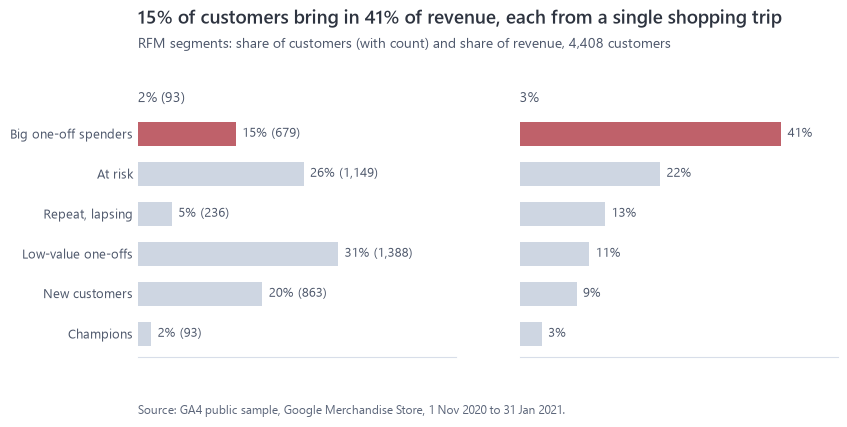

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
y = np.arange(len(seg))[::-1]
colors = [PAL["accent"] if s == "Big one-off spenders" else PAL["context"] for s in seg.segment]
for ax, col, label in [(axes[0], "share_customers", "Share of customers"), (axes[1], "share_revenue", "Share of revenue")]:
    ax.barh(y, seg[col] * 100, color=colors, height=0.6)
    for yi, v, n in zip(y, seg[col] * 100, seg.customers):
        label = f"{v:.0f}% ({n:,})" if col == "share_customers" else f"{v:.0f}%"
        ax.text(v + 1, yi, label, va="center", color=PAL["ink_2"], fontsize=9)
    ax.set_title(label, loc="left", fontsize=10, color=PAL["ink_2"])
    ax.set_xticks([]); ax.grid(False); ax.set_xlim(0, 50)
axes[0].set_yticks(y, seg.segment)
finish(fig, axes[0], "15% of customers bring in 41% of revenue, each from a single shopping trip",
       "RFM segments: share of customers (with count) and share of revenue, 4,408 customers", f"{IMG}/segments.png", top=0.72, left=0.2)
plt.show()

## 2 · Do new customers come back?

Share of each month's new customers who bought again within 30 days. Only customers with a full 30 days of follow-up are included, so January's cohort is left out.

In [4]:
orders = con.sql("select user_pseudo_id, order_date from marts.fct_orders").df()
orders["order_date"] = pd.to_datetime(orders.order_date)
first = orders.groupby("user_pseudo_id").order_date.min().rename("first")
gaps = orders.join(first, on="user_pseudo_id").assign(gap=lambda d: (d.order_date - d["first"]).dt.days)
repeat_after = gaps[gaps.gap > 0].groupby("user_pseudo_id").gap.min()
cust = first.to_frame().join(repeat_after.rename("days_to_repeat"))
cust = cust[cust["first"] <= "2021-01-01"].assign(cohort=lambda d: d["first"].dt.strftime("%b %Y"))

days = np.arange(0, 31)
curves = {c: [(g.days_to_repeat <= d).mean() * 100 for d in days] for c, g in cust.groupby("cohort")}
sizes = cust.cohort.value_counts()
{c: f"{v[-1]:.1f}% of {sizes[c]:,} customers" for c, v in curves.items()}

{'Dec 2020': '5.7% of 1,870 customers',
 'Jan 2021': '0.0% of 12 customers',
 'Nov 2020': '8.8% of 1,532 customers'}

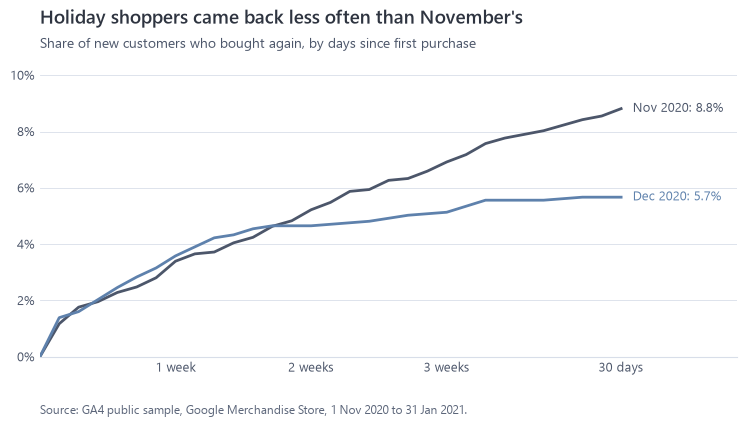

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.4))
for cohort, color in [("Nov 2020", PAL["ink_2"]), ("Dec 2020", PAL["primary"])]:
    ax.plot(days, curves[cohort], color=color, linewidth=2)
    ax.text(30.6, curves[cohort][-1], f"{cohort}: {curves[cohort][-1]:.1f}%", va="center", color=color, fontsize=9)
ax.set_xlim(0, 36); ax.set_ylim(0, 10)
ax.set_xticks([7, 14, 21, 30], ["1 week", "2 weeks", "3 weeks", "30 days"])
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
finish(fig, ax, "Holiday shoppers came back less often than November's",
       "Share of new customers who bought again, by days since first purchase", f"{IMG}/repeat_curve.png")
plt.show()

## 3 · Lifetime value: can we predict who comes back?

The BG/NBD model (`python/marketing_analytics/customers.py`, unit-tested) estimates how likely each customer is to still be active and how often they'll buy again. To check it honestly, it's fitted on November and December only, then asked to predict January.

In [6]:
calib = summarise(orders, "2021-01-01")
jan = (orders[orders.order_date >= "2021-01-01"].drop_duplicates(["user_pseudo_id", "order_date"])
       .groupby("user_pseudo_id").size())
calib["actual"] = jan.reindex(calib.index).fillna(0)
params = fit(calib.x, calib.t_x, calib["T"])
calib["predicted"] = expected_purchases(params, 31, calib.x, calib.t_x, calib["T"])
calib["quintile"] = pd.qcut(calib.predicted.rank(method="first"), 5, labels=[f"Q{i}" for i in range(1, 6)])
by_q = calib.groupby("quintile", observed=True)[["actual", "predicted"]].sum()
top_share = by_q.loc["Q5", "actual"] / by_q.actual.sum()
print(f"customers {len(calib):,} | January repeat buying days: actual {calib.actual.sum():.0f}, "
      f"predicted {calib.predicted.sum():.0f} | top fifth captured {top_share:.0%} of actual repeats")
by_q

customers 3,402 | January repeat buying days: actual 62, predicted 114 | top fifth captured 39% of actual repeats


,actual,predicted
quintile,,
Q1,4.0,13.504329
Q2,7.0,17.134633
Q3,15.0,20.864953
Q4,12.0,25.298221
Q5,24.0,36.816704


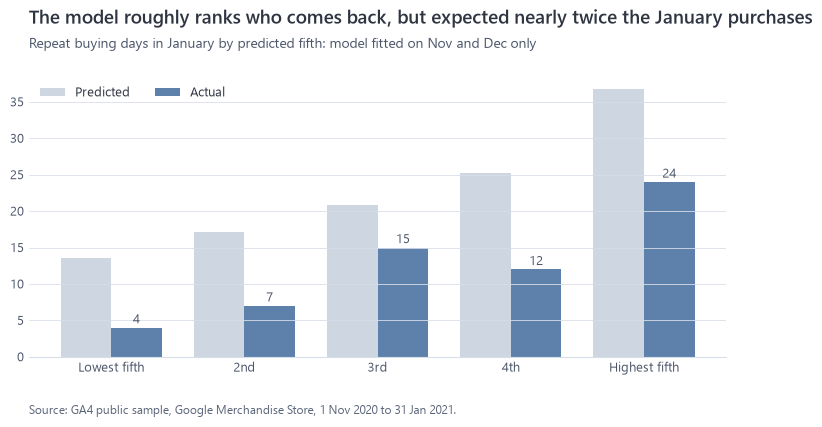

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(5); w = 0.38
ax.bar(x - w / 2, by_q.predicted, w, color=PAL["context"], label="Predicted")
ax.bar(x + w / 2, by_q.actual, w, color=PAL["primary"], label="Actual")
for xi, v in zip(x + w / 2, by_q.actual):
    ax.text(xi, v + 0.6, f"{v:.0f}", ha="center", color=PAL["ink_2"], fontsize=9)
ax.set_xticks(x, ["Lowest fifth", "2nd", "3rd", "4th", "Highest fifth"])
ax.legend(loc="upper left", ncols=2)
finish(fig, ax, "The model roughly ranks who comes back, but expected nearly twice the January purchases",
       "Repeat buying days in January by predicted fifth: model fitted on Nov and Dec only", f"{IMG}/clv_holdout.png")
plt.show()

## 4 · What to do with this

| Segment | Customers | What to do |
|---|---:|---|
| Big one-off spenders | 15% (41% of revenue) | Thank-you and second-purchase offer within two weeks, the window when repeat buyers usually return |
| At risk | 26% | One win-back email with a reason to return (new stock), then stop |
| New customers | 20% | Onboarding sequence; this is where November-style repeat rates are won or lost |
| Champions / repeat | 7% | Early access and loyalty perks; small group, highest repeat value |
| Low-value one-offs | 32% | No paid retargeting; leave to organic channels |

Limits worth saying out loud:
- Three months of data with a holiday in the middle is a short, unusual window. The model assumes steady buying, so it expected nearly twice as many January repeat purchases as happened (114 vs 62). Its ranking still helps: the top fifth it picked made 39% of January's repeat purchases, about twice what random picking gets. Use its scores to **rank** customers, not as a revenue forecast.
- Customers are browsers, so someone who buys on a phone and later on a laptop counts twice and looks less loyal than they are.
- Acquisition channel barely changes customer value here (average spend is $71 to $81 for every channel), so this data doesn't support paying more for one channel's customers.